Drift spike regions don't contain real physiological information. So, it's just noise. Removal would be better than normalization.

In [236]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [237]:
CV1_PATH = r"D:\programming\rPPg\cv_1\cv1_output.json"

with open(CV1_PATH, "r") as f:
    data = json.load(f)

subjects = data["subjects"]

In [238]:
DRIFT_PATH = r"D:\programming\rPPg\drift\drift_output.json"

with open(DRIFT_PATH, "r") as f:
    drift_data = json.load(f)

Drift Removal

In [239]:
def remove_drift(time, signal, drift_windows):
    mask = np.ones(len(time), dtype=bool)
    #assume all signal points are valid
    for w in drift_windows:
        start = w["start_time"]
        end = w["end_time"]
        mask &= ~((time >= start) & (time <= end))
        #mark points within drift windows as invalid
    clean_time = time[mask]
    clean_signal = signal[mask]
    #return only the valid points, corrupted points are removed
    return clean_time, clean_signal

Bandpass Filter

In [240]:
from scipy.signal import butter, filtfilt
#Bandpass filter to isolate heart rate frequencies (0.7 - 3 Hz)
def bandpass_filter(signal, fps, low=0.7, high=3):
    nyquist = 0.5 * fps #Nyquist frequency is half the sampling rate
    low = low / nyquist
    high = high / nyquist
    b, a = butter(3, [low, high], btype='band')#3rd order Butterworth filter
    #Apply zero-phase filtering to avoid phase distortion
    filtered = filtfilt(b, a, signal)
    return filtered

Heart Rate Estimation

In [241]:
def estimate_hr(signal, fps):

    N = len(signal)

    yf = np.abs(np.fft.rfft(signal))
    xf = np.fft.rfftfreq(N, 1/fps)
    mask = (xf >= 1.4) & (xf <= 2.2) 

    xf = xf[mask]
    yf = yf[mask]

    peak_freq = xf[np.argmax(yf)]

    hr = peak_freq * 60

    return hr

Test on 1 subject(Debug)

In [242]:
subject_id = "Subject_1"
roi = "forehead"
#Access the ROI signal extracted from CV1 data 
roi_data = subjects[subject_id]["per_frame_rgb"][roi]

time = np.array(roi_data["time_seconds"])
G = np.array(roi_data["G_per_frame"])
R = np.array(roi_data["R_per_frame"])
B = np.array(roi_data["B_per_frame"])
#Loads the drift windows for the subject and ROI from the drift detection results
drift_windows = drift_data[subject_id][roi]

In [243]:
clean_time, clean_signal = remove_drift(time, rppg, drift_windows)

print("Original signal length:", len(G))
print("Clean signal length:", len(clean_signal))

Original signal length: 1991
Clean signal length: 1698


In [244]:
fps = 1 / np.mean(np.diff(time))
rppg = G - (0.5 * R + 0.5 * B)
rppg = rppg - np.mean(rppg)
filtered_signal = bandpass_filter(rppg, fps)

hr_raw = estimate_hr(filtered_signal, fps)

clean_time, clean_signal = remove_drift(time, G, drift_windows)
fps_clean = 1 / np.mean(np.diff(clean_time))
filtered_clean = bandpass_filter(clean_signal, fps_clean)

hr_clean = estimate_hr(filtered_clean, fps_clean)

In [245]:
print(f"Estimated HR before drift removal: {hr_raw:.2f} bpm")
print(f"Estimated HR after drift removal: {hr_clean:.2f} bpm")

Estimated HR before drift removal: 102.23 bpm
Estimated HR after drift removal: 84.60 bpm


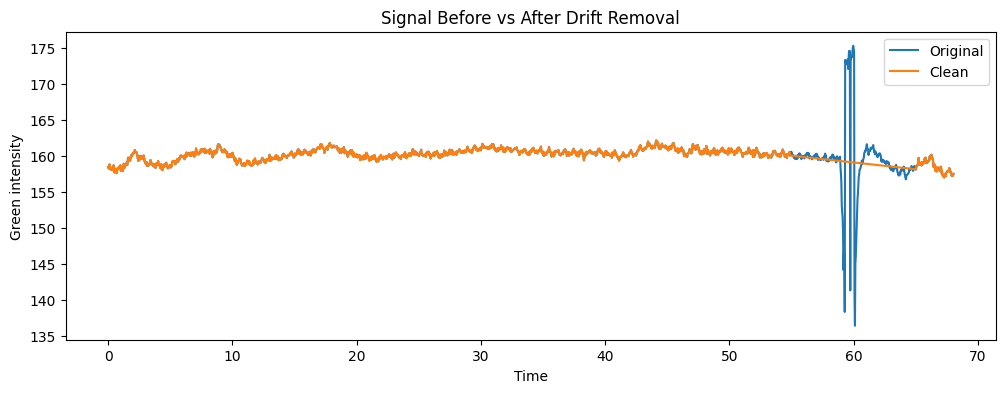

In [246]:
plt.figure(figsize=(12,4))

plt.plot(time, G, label="Original")
plt.plot(clean_time, clean_signal, label="Clean")

plt.title("Signal Before vs After Drift Removal")
plt.xlabel("Time")
plt.ylabel("Green intensity")

plt.legend()
plt.show()

In [247]:
results = {}

for subject_id, subject in subjects.items():

    print("\nProcessing:", subject_id)

    results[subject_id] = {}

    for roi in ["forehead", "left_cheek", "right_cheek"]:

        roi_data = subject["per_frame_rgb"][roi]

        time = np.array(roi_data["time_seconds"])
        R = np.array(roi_data["R_per_frame"])
        G = np.array(roi_data["G_per_frame"])
        B = np.array(roi_data["B_per_frame"])

        fps = 1 / np.mean(np.diff(time))

        # rPPG signal
        rppg = G - (0.5 * R + 0.5 * B)
        rppg = rppg - np.mean(rppg)

        # HR before drift removal
        filtered_signal = bandpass_filter(rppg, fps)
        hr_raw = estimate_hr(filtered_signal, fps)

        # Drift windows
        drift_windows = drift_data[subject_id][roi]

        # Remove drift
        clean_time, clean_signal = remove_drift(time, rppg, drift_windows)

        # Interpolate to restore signal length
        from scipy.interpolate import interp1d
        interp = interp1d(clean_time, clean_signal, fill_value="extrapolate")
        signal_resampled = interp(time)

        # Filter again
        filtered_clean = bandpass_filter(signal_resampled, fps)

        # HR after drift removal
        hr_clean = estimate_hr(filtered_clean, fps)

        results[subject_id][roi] = {
            "hr_before_drift": float(round(hr_raw,2)),
            "hr_after_drift": float(round(hr_clean,2))
        }

        print(roi, "→", "Raw:", round(hr_raw,2), "Clean:", round(hr_clean,2))

output_path = "hr_results.json"

with open(output_path, "w") as f:
    json.dump(results, f, indent=4)

print("\nResults saved to:", output_path)


Processing: Subject_1
forehead → Raw: 102.23 Clean: 89.9
left_cheek → Raw: 89.01 Clean: 86.37
right_cheek → Raw: 121.62 Clean: 85.49

Processing: Subject_2
forehead → Raw: 104.42 Clean: 104.42
left_cheek → Raw: 104.42 Clean: 104.42
right_cheek → Raw: 121.45 Clean: 121.45

Processing: Subject_3
forehead → Raw: 92.53 Clean: 92.53
left_cheek → Raw: 114.19 Clean: 114.19
right_cheek → Raw: 119.11 Clean: 119.11

Processing: Subject_4
forehead → Raw: 111.68 Clean: 111.68
left_cheek → Raw: 89.61 Clean: 89.61
right_cheek → Raw: 116.88 Clean: 116.88

Processing: Subject_5
forehead → Raw: 111.75 Clean: 111.75
left_cheek → Raw: 98.45 Clean: 98.45
right_cheek → Raw: 114.41 Clean: 114.41

Processing: Subject_6
forehead → Raw: 100.96 Clean: 100.96
left_cheek → Raw: 91.22 Clean: 91.22
right_cheek → Raw: 90.33 Clean: 90.33

Processing: Subject_7
forehead → Raw: 127.23 Clean: 127.23
left_cheek → Raw: 127.23 Clean: 127.23
right_cheek → Raw: 119.33 Clean: 125.47

Processing: Subject_8
forehead → Raw: 88.